In [1]:
!pip install optuna

In [2]:
import pandas as pd
import time
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [3]:
train_path = "/kaggle/input/datasets/vuong2901/cs114-data/train_clean.parquet"
test_path  = "/kaggle/input/datasets/vuong2901/cs114-data/test_clean.parquet"
val_path   = "/kaggle/input/datasets/vuong2901/cs114-data/val_clean.parquet"

df_train = pd.read_parquet(train_path)
df_val   = pd.read_parquet(val_path)
df_test  = pd.read_parquet(test_path)

In [4]:
print(df_train.columns)

Index(['label', 'article', 'title'], dtype='object')


In [5]:
df_trainval = pd.concat([df_train, df_val], ignore_index=True)

df_trainval["text"] = (
    df_trainval["title"].fillna("") +
    " . " +
    df_trainval["article"].fillna("")
)

df_test["text"] = (
    df_test["title"].fillna("") +
    " . " +
    df_test["article"].fillna("")
)

df_trainval["text"] = df_trainval["text"].str.lower()
df_test["text"] = df_test["text"].str.lower()

X_trainval = df_trainval["text"]
y_trainval = df_trainval["label"]

X_test = df_test["text"]
y_test = df_test["label"]

In [6]:
temp_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2)
)

temp_vectorizer.fit(X_trainval)

print("Vocabulary size:", len(temp_vectorizer.vocabulary_))

X_temp = temp_vectorizer.transform(X_trainval[:1000])

print("Shape:", X_temp.shape)

print(
    "Sparsity:",
    100.0 * (1.0 - X_temp.nnz / (
        X_temp.shape[0] * X_temp.shape[1]
    ))
)

# check actual feature count after filtering
local_vec = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_features=20000,
    min_df=5,
    max_df=0.9
)

local_vec.fit(X_trainval)

print("Filtered vocab size:", len(local_vec.vocabulary_))

Vocabulary size: 7559093
Shape: (1000, 7559093)
Sparsity: 99.99152558382335
Filtered vocab size: 20000


In [7]:
def build_vectorizer(params):
    return TfidfVectorizer(
        max_features=params["max_features"],
        ngram_range=params["ngram"],
        stop_words="english",
        min_df=params["min_df"],
        max_df=params["max_df"]
    )

In [8]:
def objective_lr(trial):

    params = {
        "max_features": trial.suggest_int(
            "max_features", 20000, 100000, step=20000
        ),

        "ngram": trial.suggest_categorical(
            "ngram", [(1,1), (1,2)]
        ),

        "min_df": trial.suggest_int("min_df", 2, 10),

        "max_df": trial.suggest_float("max_df", 0.7, 0.95),

        "C": trial.suggest_float("C", 0.1, 5.0, log=True),

        "class_weight": trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        )
    }

    skf = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in skf.split(X_trainval, y_trainval):

        X_tr = X_trainval.iloc[train_idx]
        X_va = X_trainval.iloc[val_idx]

        y_tr = y_trainval.iloc[train_idx]
        y_va = y_trainval.iloc[val_idx]

        vectorizer = build_vectorizer(params)

        X_tr_vec = vectorizer.fit_transform(X_tr)
        X_va_vec = vectorizer.transform(X_va)

        model = LogisticRegression(
            C=params["C"],
            max_iter=1000,
            class_weight=params["class_weight"],
            random_state=42
        )

        model.fit(X_tr_vec, y_tr)

        preds = model.predict(X_va_vec)

        score = f1_score(
            y_va,
            preds,
            average="weighted"
        )

        scores.append(score)

    return sum(scores) / len(scores)

study_lr = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)
study_lr.optimize(objective_lr, n_trials=60)

print("Best params LR:", study_lr.best_params)


[I 2026-05-12 07:33:49,504] A new study created in memory with name: no-name-2cf1f4bc-1019-42a9-9837-3f942fe0538f
/tmp/ipykernel_16/412102999.py:8: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  "ngram": trial.suggest_categorical(
/tmp/ipykernel_16/412102999.py:8: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  "ngram": trial.suggest_categorical(
[I 2026-05-12 07:34:58,369] Trial 0 finished with value: 0.8917771759123645 and parameters: {'max_features': 40000, 'ngram': (1, 1), 'min_df': 7, 'max_df': 0.7390046601106091, 'C': 0.18408992080552522, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8917771759123645.
/tmp/ipykernel_16/412102999.py:8: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, in

Best params LR: {'max_features': 100000, 'ngram': (1, 2), 'min_df': 3, 'max_df': 0.9040479868338536, 'C': 4.881324351777198, 'class_weight': 'balanced'}



=== Logistic Regression ===
Accuracy: 0.9139969162240877
Classification Report:
                     precision    recall  f1-score   support

  business_finance     0.9097    0.9184    0.9140       625
 culture_lifestyle     0.8855    0.8189    0.8509       878
              film     0.9203    0.9329    0.9266       879
              food     0.9649    0.9734    0.9691       564
             music     0.8782    0.9273    0.9021       770
             sport     0.9823    0.9836    0.9830       792
tech_science_games     0.9078    0.8622    0.8845       617
 world_environment     0.8733    0.9101    0.8913       712

          accuracy                         0.9140      5837
         macro avg     0.9153    0.9158    0.9152      5837
      weighted avg     0.9141    0.9140    0.9136      5837

Train time: 136.25s
Predict time/sample: 0.000004s


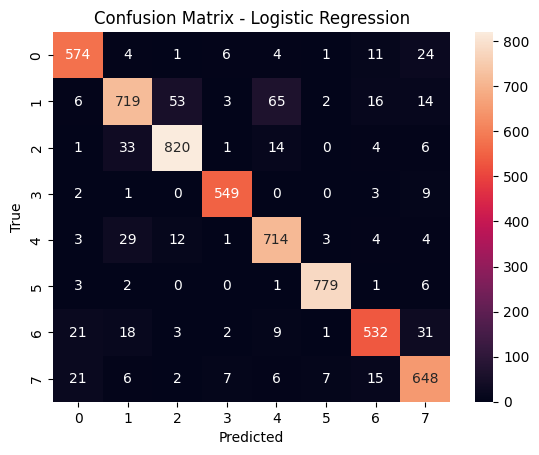

In [9]:
start = time.time()

best_lr = study_lr.best_params

vectorizer = build_vectorizer(best_lr)

X_train_vec = vectorizer.fit_transform(X_trainval)
X_test_vec = vectorizer.transform(X_test)

log_model = LogisticRegression(
    C=best_lr["C"],
    max_iter=1000,
    class_weight=best_lr["class_weight"],
    random_state=42
)

log_model.fit(X_train_vec, y_trainval)

log_train_time = time.time() - start

start = time.time()
y_pred_log = log_model.predict(X_test_vec)
log_pred_time = time.time() - start

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log, digits=4))
print(f"Train time: {log_train_time:.2f}s")
print(f"Predict time/sample: {log_pred_time / X_test.shape[0]:.6f}s")

# Confusion Matrix - Logistic
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure()
sns.heatmap(cm_log, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [10]:
def objective_svm(trial):

    params = {
        "max_features": trial.suggest_int(
            "max_features", 20000, 100000, step=20000
        ),

        "ngram": trial.suggest_categorical(
            "ngram", [(1,1), (1,2)]
        ),

        "min_df": trial.suggest_int("min_df", 2, 10),

        "max_df": trial.suggest_float("max_df", 0.7, 0.95),

        "C": trial.suggest_float("C", 0.1, 5.0, log=True),

        "class_weight": trial.suggest_categorical(
            "class_weight",
            [None, "balanced"]
        )
    }

    skf = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in skf.split(X_trainval, y_trainval):

        X_tr = X_trainval.iloc[train_idx]
        X_va = X_trainval.iloc[val_idx]

        y_tr = y_trainval.iloc[train_idx]
        y_va = y_trainval.iloc[val_idx]

        vectorizer = build_vectorizer(params)

        X_tr_vec = vectorizer.fit_transform(X_tr)
        X_va_vec = vectorizer.transform(X_va)

        model = LinearSVC(
            C=params["C"],
            class_weight=params["class_weight"],
            random_state=42
        )

        model.fit(X_tr_vec, y_tr)

        preds = model.predict(X_va_vec)

        score = f1_score(
            y_va,
            preds,
            average="weighted"
        )

        scores.append(score)

    return sum(scores) / len(scores)

study_svm = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner()
)
study_svm.optimize(objective_svm, n_trials=60)

print("Best params SVM:", study_svm.best_params)

[I 2026-05-12 11:06:25,372] A new study created in memory with name: no-name-d132c450-ffcc-476b-841a-777986c5e6c6
/tmp/ipykernel_16/1284111257.py:8: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 1) which is of type tuple.
  "ngram": trial.suggest_categorical(
/tmp/ipykernel_16/1284111257.py:8: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (1, 2) which is of type tuple.
  "ngram": trial.suggest_categorical(
[I 2026-05-12 11:07:13,258] Trial 0 finished with value: 0.909668352030864 and parameters: {'max_features': 40000, 'ngram': (1, 1), 'min_df': 7, 'max_df': 0.7390046601106091, 'C': 0.18408992080552522, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.909668352030864.
/tmp/ipykernel_16/1284111257.py:8: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, i

Best params SVM: {'max_features': 100000, 'ngram': (1, 2), 'min_df': 3, 'max_df': 0.7060345327331226, 'C': 0.6528773920663978, 'class_weight': 'balanced'}



=== Linear SVM ===
Accuracy: 0.9177659756724345
Classification Report:
                     precision    recall  f1-score   support

  business_finance     0.9227    0.9168    0.9197       625
 culture_lifestyle     0.8975    0.8178    0.8558       878
              film     0.9161    0.9443    0.9300       879
              food     0.9632    0.9734    0.9683       564
             music     0.8770    0.9351    0.9051       770
             sport     0.9776    0.9937    0.9856       792
tech_science_games     0.9207    0.8655    0.8922       617
 world_environment     0.8801    0.9073    0.8935       712

          accuracy                         0.9178      5837
         macro avg     0.9194    0.9192    0.9188      5837
      weighted avg     0.9178    0.9178    0.9172      5837

Train time: 79.44s
Predict time/sample: 0.000003s


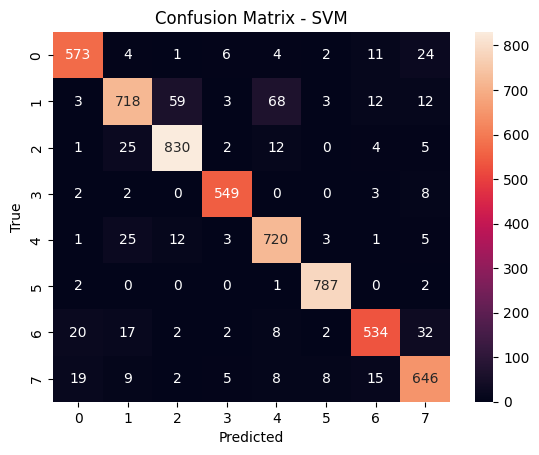

In [11]:
start = time.time()

best_svm = study_svm.best_params

vectorizer_svm = build_vectorizer(best_svm)

X_train_vec_svm = vectorizer_svm.fit_transform(X_trainval)
X_test_vec_svm = vectorizer_svm.transform(X_test)

svm_model = LinearSVC(
    C=best_svm["C"],
    class_weight=best_svm["class_weight"],
    random_state=42
)

svm_model.fit(X_train_vec_svm, y_trainval)

svm_train_time = time.time() - start

start = time.time()
y_pred_svm = svm_model.predict(X_test_vec_svm)
svm_pred_time = time.time() - start

print("\n=== Linear SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm, digits=4))
print(f"Train time: {svm_train_time:.2f}s")
print(f"Predict time/sample: {svm_pred_time / X_test.shape[0]:.6f}s")

# Confusion Matrix - SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure()
sns.heatmap(cm_svm, annot=True, fmt="d")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [12]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_svm)
    ],

    "Weighted F1": [
        f1_score(y_test, y_pred_log, average="weighted"),
        f1_score(y_test, y_pred_svm, average="weighted")
    ],

    "Train Time (s)": [
        log_train_time,
        svm_train_time
    ],

    "Predict Time/sample (s)": [
        log_pred_time / X_test.shape[0],
        svm_pred_time / X_test.shape[0]
    ]
})

print("\n=== Model Comparison ===")
print(results)
print("Best LR CV Weighted F1:", study_lr.best_value)
print("Best SVM CV Weighted F1:", study_svm.best_value)


=== Model Comparison ===
                 Model  Accuracy  Weighted F1  Train Time (s)  \
0  Logistic Regression  0.913997     0.913621      136.247012   
1                  SVM  0.917766     0.917243       79.441882   

   Predict Time/sample (s)  
0                 0.000004  
1                 0.000003  
Best LR CV Weighted F1: 0.9106292949488902
Best SVM CV Weighted F1: 0.9143385307152435


In [13]:
import numpy as np

print("\n=== Example TF-IDF Representation ===")

# lấy 1 sample từ test set
sample_idx = 0

sample_text = X_test.iloc[sample_idx]

print("\n=== Original Text ===")
print(sample_text[:1000])

# transform bằng vectorizer đã train
sample_vec = vectorizer_svm.transform([sample_text])

# convert sparse vector -> dense
sample_array = sample_vec.toarray()[0]

# lấy feature names
feature_names = vectorizer_svm.get_feature_names_out()

# lấy index các feature có tfidf > 0
nonzero_idx = sample_array.nonzero()[0]

# sort giảm dần theo tfidf
top_idx = nonzero_idx[np.argsort(sample_array[nonzero_idx])[::-1]]

print("\n=== Top TF-IDF Features ===")

print(f"{'Word':<30} TF-IDF")
print("-" * 45)

# top 20 features
for idx in top_idx[:20]:
    print(f"{feature_names[idx]:<30} {sample_array[idx]:.4f}")


=== Example TF-IDF Representation ===

=== Original Text ===
beastie boys story review – spike jonze and the boys are back in town . the release of this documentary coincides with meat20, a heart-twisting craze on social media for posting pictures of yourself at 20 years old. middle-aged people's timelines are speckled with funny, sweet and sometimes unbearably sad images of themselves in unlined, unformed youth, doing goofy things in milky analogue pictures from back when you had 12 or 24 exposures on your roll-film camera and getting them developed at boots was a pricey business. that's what i thought of while watching this engaging, oddly moving film from spike jonze: a record of the live stage show he devised at the kings theatre in brooklyn, new york, in tribute to white hip-hop stars and tongue-in-cheek party-libertarian activists the beastie boys. it is presented by the two surviving members, adam horovitz and michael diamond, in tribute to the third member, adam yauch, who die

In [14]:
feature_names = vectorizer.get_feature_names_out()

for i, class_label in enumerate(log_model.classes_):
    top10 = np.argsort(log_model.coef_[i])[-10:][::-1]
    print(f"\nTop words for class {class_label}:")
    print([feature_names[j] for j in top10])


Top words for class business_finance:
['bank', 'uk', 'money', 'property', 'business', 'customers', 'pension', 'shell', 'firm', 'account']

Top words for class culture_lifestyle:
['fashion', 'museum', 'arts', 'colbert', 'festival', 'series', 'noah', 'hair', 'heritage', 'kimmel']

Top words for class film:
['film', 'review', 'movie', 'documentary', 'actor', 'films', 'director', 'cinema', 'disney', 'depp']

Top words for class food:
['restaurant', 'wine', 'restaurants', 'recipe', 'chocolate', 'fruit', 'eat', 'cooking', 'food', 'eating']

Top words for class music:
['music', 'album', 'opera', 'singer', 'band', 'rapper', 'songs', 'concert', 'glastonbury', 'piano']

Top words for class sport:
['sport', 'team', 'players', 'race', 'champion', 'rugby', 'cricket', 'season', 'england', 'win']

Top words for class tech_science_games:
['game', 'games', 'amazon', 'puzzles', 'tiktok', 'facebook', 'uber', 'users', 'ai', 'musk']

Top words for class world_environment:
['said', 'climate', 'species', 'c

In [15]:
feature_names = vectorizer_svm.get_feature_names_out()

for i, class_label in enumerate(svm_model.classes_):
    top10 = np.argsort(svm_model.coef_[i])[-10:][::-1]

    print(f"\nTop words for class {class_label} (SVM):")
    print([feature_names[j] for j in top10])


Top words for class business_finance (SVM):
['bank', 'property', 'gsk', 'shell', 'pension', 'cormann', 'firm', 'business', 'brexit', 'customers']

Top words for class culture_lifestyle (SVM):
['fashion', 'arts', 'colbert', 'museum', 'episode', 'noah', 'kimmel', 'comedian', 'heritage', 'series']

Top words for class film (SVM):
['film', 'review', 'movie', 'documentary', 'director', 'films', 'disney', 'actor', 'depp', 'cinema']

Top words for class food (SVM):
['restaurants', 'recipe', 'restaurant', 'wine', 'fruit', 'eat', 'cooking', 'wines', 'chocolate', 'marmalade']

Top words for class music (SVM):
['album', 'music', 'rapper', 'opera', 'singer', 'band', 'glastonbury', 'concert', 'songs', 'albums']

Top words for class sport (SVM):
['sport', 'champion', 'race', 'cricket', 'rugby', 'nfl', 'team', 'season', 'afl', 'league']

Top words for class tech_science_games (SVM):
['game', 'puzzles', 'uber', 'amazon', 'games', 'users', 'musk', 'facebook', 'crypto', 'bitcoin']

Top words for class 

In [16]:
mis_idx_log = (y_test != y_pred_log)

print("\n=== Misclassified - Logistic Regression ===")

mis_indices = mis_idx_log[mis_idx_log].index[:5]

for idx in mis_indices:
    print("\nText:", X_test.iloc[idx][:1000])
    print("True:", y_test.iloc[idx])
    print("Pred:", y_pred_log[idx])

mis_idx_svm = (y_test != y_pred_svm)

print("\n=== Misclassified - SVM ===")

mis_indices = mis_idx_svm[mis_idx_svm].index[:5]

for idx in mis_indices:
    print("\nText:", X_test.iloc[idx][:1000])
    print("True:", y_test.iloc[idx])
    print("Pred:", y_pred_svm[idx])


=== Misclassified - Logistic Regression ===

Text: a sir george cayley moment on mars . in bob ward's point-missing riposte to george monbiot's criticism of the science museum's acceptance of sponsorship from shell, the words "shell" and "sponsor" are notable by their absence (letters, 22 april). he doesn't say if, as an adviser to the carbon capture exhibition, he thought shell's sponsorship was wrong, a disagreeable necessity, or just lovely. could someone ask him? a nasa representative described ingenuity's flight on mars as a wright brothers moment (report, 19 april). more accurately, it was a sir george cayley moment, as he is the father of aeronautics. in 1909, wilbur wright said of him: "about 100 years ago an englishman, sir george cayley, carried the science of flying to a point which it had never reached before." it was your other lives page that reunited me with a long-lost university friend (letters, 18 april). she recognised my mother's name and photograph, as she had sta

In [17]:
from sklearn.metrics import confusion_matrix
import numpy as np

def print_class_accuracy(y_true, y_pred, model_name):
    labels = np.unique(y_true)

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    class_acc = np.divide(
      cm.diagonal(),
      cm.sum(axis=1),
      out=np.zeros(cm.shape[0], dtype=float),
      where=cm.sum(axis=1)!=0
      )

    print(f"\n=== {model_name} - Class-wise Accuracy ===")

    for label, acc in zip(labels, class_acc):
        print(f"Class {label}: {acc:.4f}")

# Logistic
print_class_accuracy(y_test, y_pred_log, "Logistic Regression")

# SVM
print_class_accuracy(y_test, y_pred_svm, "SVM")


=== Logistic Regression - Class-wise Accuracy ===
Class business_finance: 0.9184
Class culture_lifestyle: 0.8189
Class film: 0.9329
Class food: 0.9734
Class music: 0.9273
Class sport: 0.9836
Class tech_science_games: 0.8622
Class world_environment: 0.9101

=== SVM - Class-wise Accuracy ===
Class business_finance: 0.9168
Class culture_lifestyle: 0.8178
Class film: 0.9443
Class food: 0.9734
Class music: 0.9351
Class sport: 0.9937
Class tech_science_games: 0.8655
Class world_environment: 0.9073


In [18]:
import numpy as np

importance = np.abs(svm_model.coef_).mean(axis=0)

top_global = np.argsort(importance)[-10:]

print("Global important words:")
print([feature_names[i] for i in top_global])

Global important words:
['colbert', 'documentary', 'actor', 'movie', 'album', 'music', 'game', 'fashion', 'review', 'film']


In [19]:
import joblib

joblib.dump(log_model, "logistic_model.pkl")
joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer_lr.pkl")
joblib.dump(vectorizer_svm, "tfidf_vectorizer_svm.pkl")

print("Models saved successfully!")

Models saved successfully!


In [20]:
print(df_trainval["label"].value_counts())

label
film                  4978
culture_lifestyle     4971
sport                 4488
music                 4361
world_environment     4037
business_finance      3544
tech_science_games    3496
food                  3195
Name: count, dtype: int64
